<a href="https://colab.research.google.com/github/GiovannaDuarte-dt/Criando-um-modelo-de-Machine-Learning./blob/main/Criando_um_modelo_de_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Exercício de configuração

##Instalando bibliotecas que não estão pré instaladas no google colab.


---



In [6]:
!pip install google-ml-edu==0.1.3

#Criando dependências

In [7]:
# data
import numpy as np
import pandas as pd

# machine learning
import keras
import ml_edu.experiment
import ml_edu.results

# data visualization
import plotly.express as px


In [10]:
chicago_taxi_df = pd.read_csv("https://download.mlcc.google.com/mledu-datasets/chicago_taxi_train.csv")
print(chicago_taxi_df)

        TRIP_START_TIMESTAMP      TRIP_END_TIMESTAMP  TRIP_START_HOUR  \
0      05/17/2022 7:15:00 AM   05/17/2022 7:45:00 AM             7.25   
1      05/17/2022 5:15:00 PM   05/17/2022 5:30:00 PM            17.25   
2      05/17/2022 5:15:00 PM   05/17/2022 5:30:00 PM            17.25   
3      05/17/2022 6:00:00 PM   05/17/2022 7:00:00 PM            18.00   
4      05/17/2022 5:00:00 PM   05/17/2022 5:30:00 PM            17.00   
...                      ...                     ...              ...   
31689  05/17/2022 1:15:00 PM   05/17/2022 1:30:00 PM            13.25   
31690  05/17/2022 9:45:00 PM  05/17/2022 10:15:00 PM            21.75   
31691  05/18/2022 3:45:00 AM   05/18/2022 4:00:00 AM             3.75   
31692  05/16/2022 2:45:00 PM   05/16/2022 3:30:00 PM            14.75   
31693  05/16/2022 9:30:00 PM  05/16/2022 10:00:00 PM            21.50   

       TRIP_SECONDS  TRIP_MILES  TRIP_SPEED  PICKUP_CENSUS_TRACT  \
0              2341        2.57         4.0            

In [11]:
colunas_especificas = chicago_taxi_df.loc[:, ('TRIP_MILES', 'TRIP_SECONDS', 'FARE', 'COMPANY', 'PAYMENT_TYPE', 'TIP_RATE')] #atualiza o DataFrame para usar apenas colunas específicas do conjunto de dados.

print('Read dataset completed successfully.')
print('Total number of rows: {0}\n\n'.format(len(colunas_especificas.index))) #quantidade de linhas do DataFrame
colunas_especificas.head(200) #visualizar as primeiras 200 linhas do df.

Read dataset completed successfully.
Total number of rows: 31694




,TRIP_MILES,TRIP_SECONDS,FARE,COMPANY,PAYMENT_TYPE,TIP_RATE
0,2.57,2341,31.99,Flash Cab,Mobile,6.3
1,1.18,1074,9.75,Flash Cab,Credit Card,27.9
2,1.29,1173,10.25,Sun Taxi,Cash,0.0
3,3.70,3360,23.75,Choice Taxi Association,Cash,0.0
4,1.15,1044,10.00,Flash Cab,Cash,0.0
...,...,...,...,...,...,...
195,1.13,821,9.00,Blue Ribbon Taxi Association,Mobile,22.9
196,0.57,414,6.00,Flash Cab,Cash,0.0
197,1.22,886,9.00,City Service,Cash,0.0
198,1.68,1219,9.00,Sun Taxi,Mobile,23.0


In [12]:
print('Total number of rows: {0}\n\n'.format(len(colunas_especificas.index)))
colunas_especificas.describe(include='all')

Total number of rows: 31694




,TRIP_MILES,TRIP_SECONDS,FARE,COMPANY,PAYMENT_TYPE,TIP_RATE
count,31694.000000,31694.000000,31694.000000,31694,31694,31694.000000
unique,NaN,NaN,NaN,31,7,NaN
top,NaN,NaN,NaN,Flash Cab,Credit Card,NaN
freq,NaN,NaN,NaN,7887,14142,NaN
mean,8.289463,1319.796397,23.905210,NaN,NaN,12.965785
std,7.265672,928.932873,16.970022,NaN,NaN,15.517765
min,0.500000,60.000000,3.250000,NaN,NaN,0.000000
25%,1.720000,548.000000,9.000000,NaN,NaN,0.000000
50%,5.920000,1081.000000,18.750000,NaN,NaN,12.200000
75%,14.500000,1888.000000,38.750000,NaN,NaN,20.800000


#Respondendo algumas perguntas chaves.

## Qual é a tarifa máxima?
##Qual é a distância média percorrida em todas as viagens?
##Quantas empresas de táxi estão presentes no conjunto de dados?
##Qual é o tipo de pagamento mais frequente?
##Há alguma funcionalidade com dados faltantes?

##

In [ ]:
valor_faremax = colunas_especificas["FARE"].max()
valor_faremax

159.25

In [ ]:
distancia_mediatripmiles = colunas_especificas["TRIP_MILES"].mean()
distancia_mediatripmiles

np.float64(8.289462674323214)

In [ ]:
quantidade_empresas = colunas_especificas["COMPANY"].count()
quantidade_empresas

np.int64(31694)

In [ ]:
pagamento_mfrequente = colunas_especificas["PAYMENT_TYPE"].mode()
pagamento_mfrequente

,PAYMENT_TYPE
0,Credit Card


In [ ]:
funcionalidades_faltantes = colunas_especificas.isnull().sum().sum()
funcionalidades_faltantes

np.int64(0)

##Matriz de correlação

In [ ]:
colunas_especificas.corr(numeric_only = True)

,TRIP_MILES,TRIP_SECONDS,FARE,TIP_RATE
TRIP_MILES,1.000000,0.800855,0.975344,-0.049594
TRIP_SECONDS,0.800855,1.000000,0.830292,-0.084294
FARE,0.975344,0.830292,1.000000,-0.070979
TIP_RATE,-0.049594,-0.084294,-0.070979,1.000000


##Qual característica apresenta a correlação mais forte com o rótulo FARE?

##A característica da coluna "trip_miles"

##Qual característica apresenta a menor correlação com o rótulo FARE?

##A característica da coluna "trip_rate"

##Criando um ***gráfico de pares*** para estabelecer uma relação entre as caracteristicas do conjunto de dados.

In [13]:
px.scatter_matrix(colunas_especificas, dimensions=["FARE", "TRIP_MILES", "TRIP_SECONDS"])

#Criando funções para treinar e construir o novo modelo.

In [20]:

#Esta função monta a estrutura da rede neural para uma regressão linear.
def funcao1 (
    settings: ml_edu.experiment.ExperimentSettings,
    metrics: list[keras.metrics.Metric],
) -> keras.Model:

  #Cria uma camada de entrada para cada característica configurada nas configurações.
  inputs = {name: keras.Input(shape=(1,), name=name) for name in settings.input_features}
  #Junta todas essas entradas em um único vetor para que a rede consiga processá-las juntas.
  concatenated_inputs = keras.layers.Concatenate()(list(inputs.values()))
  #Usa uma camada densa (Dense(units=1)) com apenas 1 nó, pois a regressão linear calcula um único valor contínuo como resposta.
  outputs = keras.layers.Dense(units=1)(concatenated_inputs)
  #Prepara o modelo para o treino.
  model = keras.Model(inputs=inputs, outputs=outputs)

#Otimizador (RMSprop): O algoritmo que ajusta os pesos para melhorar os palpites do modelo. Perda (loss="mean_squared_error"):
#A métrica do erro quadrático médio, usada para medir o quão longe os palpites estão da resposta correta:

  model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=settings.learning_rate),
                loss="mean_squared_error",
                metrics=metrics)

  return model

#Esta função pega os dados reais e faz a rede aprender com eles.
def treinamentoML (
    experiment_name: str,
    model: keras.Model,
    dataset: pd.DataFrame,
    label_name: str,
    settings: ml_edu.experiment.ExperimentSettings,
) -> ml_edu.experiment.Experiment:

#Separação dos dados (features e label): Separa as colunas de entrada (features, o que você usa para prever) e a coluna alvo (label, o que você quer prever).
#Treinamento (model.fit): Executa o ciclo de aprendizado repetindo o processo pelo número estipulado de épocas (epochs), ajustando os pesos a cada lote de dados (batch_size).

  features = {name: dataset[name].values for name in settings.input_features}
  label = dataset[label_name].values
  history = model.fit(x=features,
                      y=label,
                      batch_size=settings.batch_size,
                      epochs=settings.number_epochs)

#Retorno: Devolve um objeto Experiment contendo o modelo treinado e o histórico do treinamento (como a perda mudou ao longo das épocas).

  return ml_edu.experiment.Experiment(
      name=experiment_name,
      settings=settings,
      model=model,
      epochs=history.epoch,
      metrics_history=pd.DataFrame(history.history),
  )

print("SUCCESS: defining linear regression functions complete.")

#OBS: Em termos de Machine Learning,
#o conceito utilizado é totalmente genérico
#— trata-se de uma Regressão Linear padrão.
#No entanto,
##a forma como o código recebe e processa os dados
#foi adaptada especificamente
#para se integrar ao dataset
#e às rotinas da biblioteca ml_edu.

SUCCESS: defining linear regression functions complete.


##Nesta etapa, você treinará um modelo para prever o custo da tarifa usando uma única característica. Anteriormente, você viu que a TRIP_MILES (distância) tem a correlação mais forte com a tarifa (FARE), então vamos começar com a TRIP_MILES (distância) como a característica para sua primeira execução de treinamento.

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1014.9042 - rmse: 31.8576
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 608.1780 - rmse: 24.6613
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 306.5443 - rmse: 17.5084
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 113.4730 - rmse: 10.6524
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 26.2716 - rmse: 5.1256
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 15.2357 - rmse: 3.9033
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.6658 - rmse: 3.8296
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.3342 - rmse: 3.7860
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.1681 - rmse: 3.7641
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.0901 - rmse: 3.7537
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.0539 - rmse: 3.7489
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.0405 - rmse:

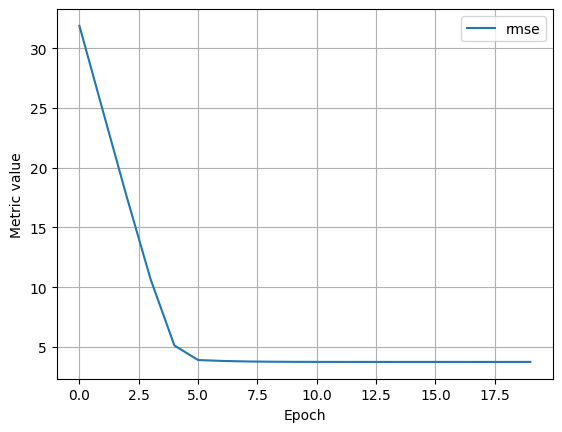

In [24]:
#Definindo os hiperparametros:

settings_1 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 20,
    batch_size = 50,
    input_features = ['TRIP_MILES']
)
 #Define o erro quadrático médio (RMSE) para medir o desempenho do modelo.
metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

#Instancia o modelo e o treina para prever o valor da tarifa (FARE) com base nas milhas rodadas.
model_1 = funcao1(settings_1, metrics)
experiment_1 = treinamentoML('one_feature', model_1, colunas_especificas, 'FARE', settings_1)

#Gera dois gráficos: um mostrando a evolução da métrica de erro ao longo do treino e outro comparando as previsões do modelo com os dados reais.

ml_edu.results.plot_experiment_metrics(experiment_1, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_1, colunas_especificas, 'FARE')

#Variação de hiperparametro.

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 48.7718 - rmse: 6.9837
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 47.9337 - rmse: 6.9234
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 46.7776 - rmse: 6.8394
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 47.8004 - rmse: 6.9138
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 47.8989 - rmse: 6.9209
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 47.7192 - rmse: 6.9079
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 48.7322 - rmse: 6.9808
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 48.2859 - rmse: 6.9488
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 47.7287 - rmse: 6.9086
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 47.2121 - rmse: 6.8711
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 48.1233 - rmse: 6.9371
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 47.9693 - rmse: 6.9260
E

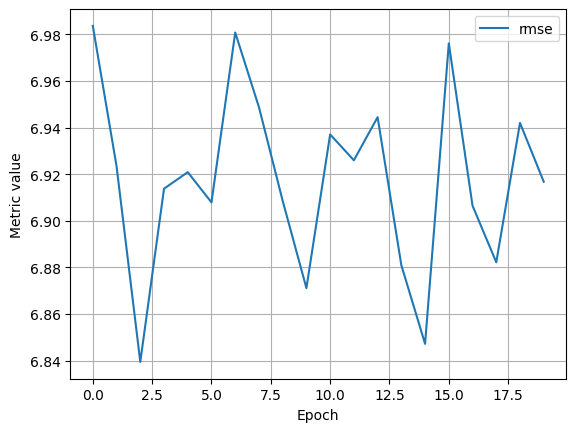

In [27]:
settings_2 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 1.0,
    number_epochs = 20,
    batch_size = 50,
    input_features = ['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_2 = funcao1(settings_2, metrics)

experiment_2 = treinamentoML('one_feature_hyper', model_2, colunas_especificas, 'FARE', settings_2)

ml_edu.results.plot_experiment_metrics(experiment_2, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_2, colunas_especificas, 'FARE')

#Aumentar a taxa de aprendizado acima fez o modelo nunca convergir.

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 974.1531 - rmse: 31.2114 
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 929.2258 - rmse: 30.4832
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 885.3718 - rmse: 29.7552
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 842.7237 - rmse: 29.0297
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 801.0029 - rmse: 28.3020
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 760.5397 - rmse: 27.5779
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 721.2077 - rmse: 26.8553
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 682.7180 - rmse: 26.1289
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 645.7275 - rmse: 25.4112
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 609.1759 - rmse: 24.6815
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 574.2902 - rmse: 23.9644
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


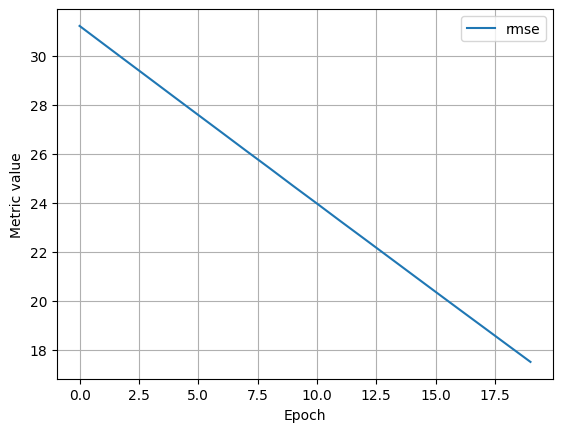

In [28]:
settings_2 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.0001,
    number_epochs = 20,
    batch_size = 50,
    input_features = ['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_2 = funcao1(settings_2, metrics)

experiment_2 = treinamentoML('one_feature_hyper', model_2, colunas_especificas, 'FARE', settings_2)

ml_edu.results.plot_experiment_metrics(experiment_2, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_2, colunas_especificas, 'FARE')

#O modelo, como mostra acima, vai demorar muito mais para convergir.

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1871.6038 - rmse: 43.2620
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1806.5558 - rmse: 42.5036
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1743.4392 - rmse: 41.7545
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1681.4373 - rmse: 41.0053
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1620.3381 - rmse: 40.2534
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1561.2174 - rmse: 39.5122
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1502.7507 - rmse: 38.7653
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1445.2394 - rmse: 38.0163
Epoch 9/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1388.8501 - rmse: 37.2673
Epoch 10/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1333.8441 - rmse: 36.5218
Epoch 11/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1279.5764 - rmse: 35.7712
Epoch 12/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1226.8365 - rms

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


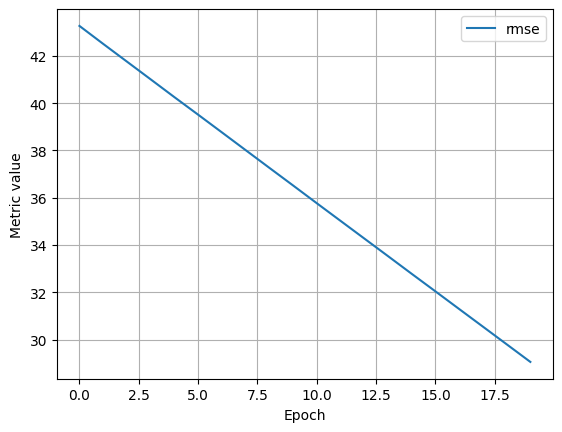

In [30]:
settings_2 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 20,
    batch_size = 500,
    input_features = ['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_2 = funcao1(settings_2, metrics)

experiment_2 = treinamentoML('one_feature_hyper', model_2, colunas_especificas, 'FARE', settings_2)

ml_edu.results.plot_experiment_metrics(experiment_2, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_2, colunas_especificas, 'FARE')

#Pela quantidade de Lotes acima, o modelo também vai demorar muito para convergir.

#Modelo usando duas variáveis em vez de uma.

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 52.6909 - rmse: 7.2588
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 21.3551 - rmse: 4.6212
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 16.2914 - rmse: 4.0363
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.3809 - rmse: 3.7922
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13.4695 - rmse: 3.6701
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.8977 - rmse: 3.5913
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.5373 - rmse: 3.5408
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 12.3140 - rmse: 3.5091
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 12.2051 - rmse: 3.4936
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.1478 - rmse: 3.4854
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.1218 - rmse: 3.4816
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.1077 - rmse: 3.4796
E

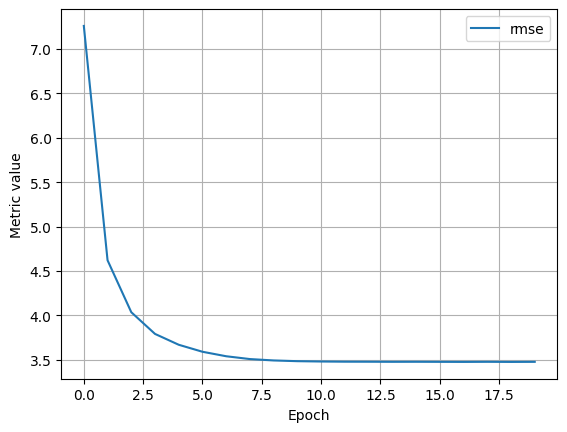

In [33]:
settings_3 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 20,
    batch_size = 50,
    input_features = ['TRIP_MILES', 'TRIP_MINUTES']
)

#Cria a nova coluna TRIP_MINUTES no DataFrame dividindo o tempo total em segundos (TRIP_SECONDS) por $60$.
colunas_especificas['TRIP_MINUTES'] = colunas_especificas['TRIP_SECONDS']/60

#Define novamente o erro quadrático médio (RMSE) para acompanhar o desempenho.
metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

#Instancia e treina o modelo para prever o valor da tarifa (FARE) usando a combinação da distância e da duração da viagem.
model_3 = funcao1(settings_3, metrics)
experiment_3 = treinamentoML('two_features', model_3, colunas_especificas, 'FARE', settings_3)


#Gera os gráficos para analisar a evolução do erro e a qualidade das previsões.
ml_edu.results.plot_experiment_metrics(experiment_3, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_3, colunas_especificas, 'FARE')

Para fazer previsões futuras baseado no modelo:

In [37]:
def format_currency(x):
  return "${:.2f}".format(x)

def build_batch(df, batch_size):
  batch = df.sample(n=batch_size).copy()
  batch.set_index(np.arange(batch_size), inplace=True)
  return batch

def predict_fare(model, df, features, label, batch_size=50):
  batch = build_batch(df, batch_size)
  predicted_values = model.predict_on_batch(x={name: batch[name].values for name in features})

  data = {"PREDICTED_FARE": [], "OBSERVED_FARE": [], "L1_LOSS": [],
          features[0]: [], features[1]: []}
  for i in range(batch_size):
    predicted = predicted_values[i][0]
    observed = batch.at[i, label]
    data["PREDICTED_FARE"].append(format_currency(predicted))
    data["OBSERVED_FARE"].append(format_currency(observed))
    data["L1_LOSS"].append(format_currency(abs(observed - predicted)))
    data[features[0]].append(batch.at[i, features[0]])
    data[features[1]].append("{:.2f}".format(batch.at[i, features[1]]))

  output_df = pd.DataFrame(data)
  return output_df

def show_predictions(output):
  header = "-" * 80
  banner = header + "\n" + "|" + "PREDICTIONS".center(78) + "|" + "\n" + header
  print(banner)
  print(output)
  return
output = predict_fare(experiment_3.model, colunas_especificas, experiment_3.settings.input_features, 'FARE')
show_predictions(output)

--------------------------------------------------------------------------------
|                                 PREDICTIONS                                  |
--------------------------------------------------------------------------------
   PREDICTED_FARE OBSERVED_FARE L1_LOSS  TRIP_MILES TRIP_MINUTES
0          $27.35        $27.50   $0.15       10.55        15.02
1          $13.64        $12.96   $0.68        3.77        15.12
2           $9.25         $9.00   $0.25        1.84        11.77
3          $30.67        $30.50   $0.17       11.62        22.93
4          $14.78        $15.50   $0.72        3.64        24.78
5          $12.38        $11.75   $0.63        3.30        13.00
6           $8.07         $7.75   $0.32        1.48         8.63
7           $8.42         $8.00   $0.42        1.70         8.00
8           $6.86         $9.00   $2.14        1.06         6.13
9          $43.77        $42.50   $1.27       17.30        34.00
10         $29.86        $29.25   $0.61   